# Gaussian Process multi-objective hyperparameter experiment v2: bias-aware

This notebook extends the first GP multi-objective experiment.

Version 1 optimized GP hyperparameters using two objectives:

1. monthly NBS RMSE
2. 6-month integrated NBS RMSE

The results showed that this could slightly improve integrated RMSE, but sometimes increased cumulative bias. Since USACE has identified systematic offset/drift in cumulative NBS as a key concern, this version adds a third objective:

3. mean absolute lake-level 6-month integrated NBS bias

The purpose is to search for GP hyperparameters that preserve monthly and integrated skill while reducing cumulative drift.

## 1. Install optional dependency

In [1]:
# Uncomment if needed.
# !pip install platypus-opt

## 2. Imports and setup

In [2]:
import os
import sys
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RationalQuadratic
from sklearn.metrics import mean_squared_error, r2_score

from platypus import NSGAII, Problem, Real

import joblib

In [3]:
sys.path.append(os.path.abspath("../../"))

from src.data_processor import CFSTransformer
from src.data_loader import DataLoader

## 3. User inputs

In [4]:
local_path = "/Users/dannes/Documents/cnbs-predictor-dev/"
input_dir = local_path + "cnbs-predictor/data/"

train_start_date = "1981-09-01"
train_end_date = "2005-12-01"

val_start_date = "2006-01-01"
val_end_date = "2010-03-01"

random_state = 42

lakes = ["superior", "michigan-huron", "erie", "ontario"]

# Keep this modest at first. GP fitting is expensive.
nsgaii_evaluations = 30

## 4. Load CFSR features

In [5]:
pcp_data = pd.read_csv(input_dir + "cfsr/CFSR_APCP_Basin_Avgs.csv")
evap_data = pd.read_csv(input_dir + "cfsr/CFSR_EVAP_Basin_Avgs.csv")
tmp_data = pd.read_csv(input_dir + "cfsr/CFSR_TMP_Basin_Avgs.csv")

pcp_data["date"] = pd.to_datetime(pcp_data[["year", "month"]].assign(day=1))

X = pd.DataFrame({
    "superior_lake_precipitation": pcp_data["sup_lake"],
    "michigan-huron_lake_precipitation": pcp_data["mih_lake"],
    "erie_lake_precipitation": pcp_data["eri_lake"],
    "ontario_lake_precipitation": pcp_data["ont_lake"],

    "superior_land_precipitation": pcp_data["sup_land"],
    "michigan-huron_land_precipitation": pcp_data["mih_land"],
    "erie_land_precipitation": pcp_data["eri_land"],
    "ontario_land_precipitation": pcp_data["ont_land"],

    "superior_lake_evaporation": evap_data["sup_lake"],
    "michigan-huron_lake_evaporation": evap_data["mih_lake"],
    "erie_lake_evaporation": evap_data["eri_lake"],
    "ontario_lake_evaporation": evap_data["ont_lake"],

    "superior_land_evaporation": evap_data["sup_land"],
    "michigan-huron_land_evaporation": evap_data["mih_land"],
    "erie_land_evaporation": evap_data["eri_land"],
    "ontario_land_evaporation": evap_data["ont_land"],

    "superior_lake_air_temperature": tmp_data["sup_lake"],
    "michigan-huron_lake_air_temperature": tmp_data["mih_lake"],
    "erie_lake_air_temperature": tmp_data["eri_lake"],
    "ontario_lake_air_temperature": tmp_data["ont_lake"],

    "superior_land_air_temperature": tmp_data["sup_land"],
    "michigan-huron_land_air_temperature": tmp_data["mih_land"],
    "erie_land_air_temperature": tmp_data["eri_land"],
    "ontario_land_air_temperature": tmp_data["ont_land"],
})

X.set_index(pd.to_datetime(pcp_data[["year", "month"]].assign(day=1)), inplace=True)

X_shifted = CFSTransformer(X).shift_variables(lag=0, lead=10)

X_shifted = pd.concat(
    [
        X_shifted,
        pd.DataFrame({"month": X_shifted.index.month}, index=X_shifted.index),
    ],
    axis=1,
)

X_shifted = pd.get_dummies(X_shifted, columns=["month"], prefix="month")

feature_column_order = (
    [f"month_{i}" for i in range(1, 13)]
    + [
        f"{lake}_{surface_type}_{comp}_mo{m}"
        for lake in lakes
        for surface_type in ["lake", "land"]
        for comp in ["precipitation", "evaporation", "air_temperature"]
        for m in range(10)
    ]
)

X_reorg = X_shifted.reindex(columns=feature_column_order)

dataloader = DataLoader()
df_sst_k = dataloader.glsea(input_dir + "glsea/oisst_sst_1981-2024.csv", units="K")

X_merged = pd.merge(df_sst_k, X_reorg, left_index=True, right_index=True, how="inner")

print(X_merged.shape)
X_merged.head()

(343, 256)


,superior_sst,michigan-huron_sst,erie_sst,ontario_sst,month_1,month_2,month_3,month_4,month_5,month_6,...,ontario_land_air_temperature_mo0,ontario_land_air_temperature_mo1,ontario_land_air_temperature_mo2,ontario_land_air_temperature_mo3,ontario_land_air_temperature_mo4,ontario_land_air_temperature_mo5,ontario_land_air_temperature_mo6,ontario_land_air_temperature_mo7,ontario_land_air_temperature_mo8,ontario_land_air_temperature_mo9
date,,,,,,,,,,,,,,,,,,,,,
1981-09-01,289.16,292.925,295.60,293.36,False,False,False,False,False,False,...,286.578745,279.378374,275.202487,269.329360,261.010883,264.987021,270.307318,276.388563,286.613505,288.144814
1981-10-01,280.79,285.910,289.04,286.56,False,False,False,False,False,False,...,279.378374,275.202487,269.329360,261.010883,264.987021,270.307318,276.388563,286.613505,288.144814,293.056232
1981-11-01,279.02,281.815,284.75,283.00,False,False,False,False,False,False,...,275.202487,269.329360,261.010883,264.987021,270.307318,276.388563,286.613505,288.144814,293.056232,290.109434
1981-12-01,278.01,279.230,280.41,279.62,False,False,False,False,False,False,...,269.329360,261.010883,264.987021,270.307318,276.388563,286.613505,288.144814,293.056232,290.109434,287.470924
1982-01-01,276.40,276.885,275.64,275.59,True,False,False,False,False,False,...,261.010883,264.987021,270.307318,276.388563,286.613505,288.144814,293.056232,290.109434,287.470924,282.101856


## 5. Load targets

This mirrors the production training file: precipitation, evaporation, runoff, and NBS are all included as targets. The multi-objective evaluation focuses on NBS.

In [6]:
l2 = dataloader.l2swbm(input_dir + "l2swbm/")
glcc = dataloader.glcc(input_dir + "glcc/", units="mm")

targets = pd.DataFrame({
    "superior_target_evaporation": l2["superior_evaporation_obs"],
    "superior_target_precipitation": l2["superior_precipitation_obs"],
    "superior_target_runoff": l2["superior_runoff_obs"],
    "superior_target_nbs": glcc["superior_nbs_obs"],

    "michigan-huron_target_evaporation": l2["michigan-huron_evaporation_obs"],
    "michigan-huron_target_precipitation": l2["michigan-huron_precipitation_obs"],
    "michigan-huron_target_runoff": l2["michigan-huron_runoff_obs"],
    "michigan-huron_target_nbs": glcc["michigan-huron_nbs_obs"],

    "erie_target_evaporation": l2["erie_evaporation_obs"],
    "erie_target_precipitation": l2["erie_precipitation_obs"],
    "erie_target_runoff": l2["erie_runoff_obs"],
    "erie_target_nbs": glcc["erie_nbs_obs"],

    "ontario_target_evaporation": l2["ontario_evaporation_obs"],
    "ontario_target_precipitation": l2["ontario_precipitation_obs"],
    "ontario_target_runoff": l2["ontario_runoff_obs"],
    "ontario_target_nbs": glcc["ontario_nbs_obs"],
}).dropna()

targets_lead = CFSTransformer(targets).shift_variables(lag=0, lead=12)

target_column_order = [
    f"{lake}_target_{comp}_mo{m}"
    for lake in lakes
    for comp in ["precipitation", "evaporation", "runoff", "nbs"]
    for m in range(12)
]

targets_reorg = targets_lead.reindex(columns=target_column_order)

aligned_X, aligned_y = X_merged.align(targets_reorg, join="inner", axis=0)

print(f"Number of features: {aligned_X.shape[1]}")
print(f"Number of targets: {aligned_y.shape[1]}")

Number of features: 256
Number of targets: 192


## 6. Train/test split and scaling

In [7]:
X_train = aligned_X[train_start_date:train_end_date]
y_train = aligned_y[train_start_date:train_end_date]

X_test = aligned_X[val_start_date:val_end_date]
y_test = aligned_y[val_start_date:val_end_date]

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)

y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

print(X_train_scaled.shape, y_train_scaled.shape)
print(X_test_scaled.shape, y_test_scaled.shape)

(292, 256) (292, 192)
(51, 256) (51, 192)


## 7. Evaluation helpers

In [8]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def unscale_to_df(y_scaled, scaler, index, columns):
    return pd.DataFrame(
        scaler.inverse_transform(y_scaled),
        index=index,
        columns=columns,
    )


def nbs_columns(columns):
    return [c for c in columns if "_target_nbs_mo" in c]


def monthly_nbs_rmse(y_true_df, y_pred_df):
    cols = nbs_columns(y_true_df.columns)
    yt = y_true_df[cols].to_numpy().ravel()
    yp = y_pred_df[cols].to_numpy().ravel()
    return rmse(yt, yp)


def lake_window_values(y_true_df, y_pred_df, lake, window=6):
    cols = [f"{lake}_target_nbs_mo{i}" for i in range(12)]
    yt = y_true_df[cols].to_numpy()
    yp = y_pred_df[cols].to_numpy()

    values_true = []
    values_pred = []

    for start in range(12 - window + 1):
        values_true.append(yt[:, start:start + window].sum(axis=1))
        values_pred.append(yp[:, start:start + window].sum(axis=1))

    return np.concatenate(values_true), np.concatenate(values_pred)


def six_month_integrated_nbs_rmse(y_true_df, y_pred_df):
    values_true = []
    values_pred = []

    for lake in lakes:
        yt, yp = lake_window_values(y_true_df, y_pred_df, lake, window=6)
        values_true.append(yt)
        values_pred.append(yp)

    yt_all = np.concatenate(values_true)
    yp_all = np.concatenate(values_pred)

    return rmse(yt_all, yp_all)


def six_month_integrated_nbs_bias(y_true_df, y_pred_df):
    values_true = []
    values_pred = []

    for lake in lakes:
        yt, yp = lake_window_values(y_true_df, y_pred_df, lake, window=6)
        values_true.append(yt)
        values_pred.append(yp)

    yt_all = np.concatenate(values_true)
    yp_all = np.concatenate(values_pred)

    return np.mean(yp_all - yt_all)


def lake_level_six_month_biases(y_true_df, y_pred_df):
    out = {}

    for lake in lakes:
        yt, yp = lake_window_values(y_true_df, y_pred_df, lake, window=6)
        out[lake] = np.mean(yp - yt)

    return out


def mean_abs_lake_level_six_month_bias(y_true_df, y_pred_df):
    biases = lake_level_six_month_biases(y_true_df, y_pred_df)
    return np.mean(np.abs(list(biases.values())))


def max_abs_lake_level_six_month_bias(y_true_df, y_pred_df):
    biases = lake_level_six_month_biases(y_true_df, y_pred_df)
    return np.max(np.abs(list(biases.values())))


def evaluate_prediction(y_pred_scaled, label):
    y_true_df = unscale_to_df(y_test_scaled, y_scaler, y_test.index, y_test.columns)
    y_pred_df = unscale_to_df(y_pred_scaled, y_scaler, y_test.index, y_test.columns)

    lake_biases = lake_level_six_month_biases(y_true_df, y_pred_df)

    metrics = {
        "label": label,
        "monthly_nbs_rmse": monthly_nbs_rmse(y_true_df, y_pred_df),
        "six_month_integrated_nbs_rmse": six_month_integrated_nbs_rmse(y_true_df, y_pred_df),
        "six_month_integrated_nbs_bias": six_month_integrated_nbs_bias(y_true_df, y_pred_df),
        "mean_abs_lake_level_six_month_bias": mean_abs_lake_level_six_month_bias(y_true_df, y_pred_df),
        "max_abs_lake_level_six_month_bias": max_abs_lake_level_six_month_bias(y_true_df, y_pred_df),
        "overall_scaled_r2": r2_score(y_test_scaled, y_pred_scaled),
    }

    for lake, bias in lake_biases.items():
        metrics[f"{lake}_six_month_bias"] = bias

    return metrics

## 8. Production-style GP baseline

In [9]:
baseline_kernel = 1.0 * Matern(nu=1.5) * RationalQuadratic()

baseline_gp = GaussianProcessRegressor(
    kernel=baseline_kernel,
    alpha=0.1,
    n_restarts_optimizer=10,
    random_state=random_state,
)

baseline_gp.fit(X_train_scaled, y_train_scaled)
y_pred_baseline_scaled = baseline_gp.predict(X_test_scaled)

baseline_metrics = evaluate_prediction(y_pred_baseline_scaled, "production_style_gp")

print("Optimized kernel:", baseline_gp.kernel_)
baseline_metrics

Optimized kernel: 3.99**2 * Matern(length_scale=113, nu=1.5) * RationalQuadratic(alpha=0.000102, length_scale=1e-05)


/Users/dannes/miniconda/miniconda3/envs/nbs_env/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


{'label': 'production_style_gp',
 'monthly_nbs_rmse': np.float64(56.80342403466506),
 'six_month_integrated_nbs_rmse': np.float64(132.92130040564987),
 'six_month_integrated_nbs_bias': np.float64(19.449344390127525),
 'mean_abs_lake_level_six_month_bias': np.float64(25.32455875500591),
 'max_abs_lake_level_six_month_bias': np.float64(65.30908935159923),
 'overall_scaled_r2': 0.7608487134298926,
 'superior_six_month_bias': np.float64(65.30908935159923),
 'michigan-huron_six_month_bias': np.float64(15.201193237132468),
 'erie_six_month_bias': np.float64(9.037523701535173),
 'ontario_six_month_bias': np.float64(-11.75042872975676)}

## 9. Bias-aware multi-objective GP candidate evaluator

The outer optimizer proposes GP hyperparameters. For each candidate, we minimize:

1. monthly NBS RMSE
2. 6-month integrated NBS RMSE
3. mean absolute lake-level 6-month integrated NBS bias

The third objective prevents bias cancellation across lakes.

In [10]:
evaluation_log = []

def build_gp_from_hyperparams(hyperparams):
    matern_length_scale, rq_alpha, rq_length_scale, gp_alpha = hyperparams

    kernel = (
        1.0
        * Matern(length_scale=matern_length_scale, nu=1.5)
        * RationalQuadratic(alpha=rq_alpha, length_scale=rq_length_scale)
    )

    return GaussianProcessRegressor(
        kernel=kernel,
        alpha=gp_alpha,
        optimizer=None,
        normalize_y=False,
        random_state=random_state,
    )


def gp_multiobjective_cost(hyperparams):
    try:
        gp = build_gp_from_hyperparams(hyperparams)
        gp.fit(X_train_scaled, y_train_scaled)
        y_pred_scaled = gp.predict(X_test_scaled)

        metrics = evaluate_prediction(
            y_pred_scaled,
            label="candidate_gp",
        )

        obj_monthly = metrics["monthly_nbs_rmse"]
        obj_cumulative = metrics["six_month_integrated_nbs_rmse"]
        obj_bias = metrics["mean_abs_lake_level_six_month_bias"]

        evaluation_log.append({
            "matern_length_scale": hyperparams[0],
            "rq_alpha": hyperparams[1],
            "rq_length_scale": hyperparams[2],
            "gp_alpha": hyperparams[3],
            **metrics,
        })

        print(
            f"monthly={obj_monthly:.3f}, "
            f"six_month={obj_cumulative:.3f}, "
            f"mean_abs_bias={obj_bias:.3f}, "
            f"global_bias={metrics['six_month_integrated_nbs_bias']:.3f}, "
            f"params={hyperparams}"
        )

        return [obj_monthly, obj_cumulative, obj_bias]

    except Exception as exc:
        print(f"Candidate failed: {hyperparams} -> {exc}")
        return [1e9, 1e9, 1e9]

## 10. Run NSGA-II search

In [11]:
problem = Problem(4, 3)

problem.types[:] = [
    Real(0.1, 100.0),   # Matern length scale
    Real(0.01, 10.0),   # RationalQuadratic alpha
    Real(0.1, 100.0),   # RationalQuadratic length scale
    Real(1e-4, 1.0),    # GP alpha / noise level
]

problem.function = gp_multiobjective_cost

algorithm = NSGAII(problem)
algorithm.run(nsgaii_evaluations)

monthly=56.983, six_month=132.975, mean_abs_bias=26.098, global_bias=23.065, params=[49.98142278860442, 9.734661819863087, 49.82633722153749, 0.046158287268805255]
monthly=120.414, six_month=417.544, mean_abs_bias=66.728, global_bias=-19.836, params=[0.8934950181391696, 7.244706765976394, 28.978354650703942, 0.3139924939109751]
monthly=60.763, six_month=149.594, mean_abs_bias=35.499, global_bias=14.920, params=[87.39129129386603, 3.8342341635465274, 59.04426900693801, 0.14712994676781577]
monthly=68.825, six_month=185.836, mean_abs_bias=52.077, global_bias=3.824, params=[57.27137532302365, 3.336771910189661, 82.29083796817969, 0.7252188322129705]
monthly=68.995, six_month=185.747, mean_abs_bias=52.166, global_bias=3.379, params=[89.60191070906, 6.1312629417264, 52.2658458770618, 0.66315109104604]
monthly=66.799, six_month=175.857, mean_abs_bias=48.437, global_bias=6.733, params=[81.44485756250258, 7.534496102935484, 89.28927359408603, 0.3499232256485189]
monthly=65.125, six_month=169.3

## 11. Inspect candidate results

In [12]:
eval_df = pd.DataFrame(evaluation_log)
eval_df = eval_df.sort_values(
    [
        "mean_abs_lake_level_six_month_bias",
        "six_month_integrated_nbs_rmse",
        "monthly_nbs_rmse",
    ]
).reset_index(drop=True)

eval_df.head(20)

,matern_length_scale,rq_alpha,rq_length_scale,gp_alpha,label,monthly_nbs_rmse,six_month_integrated_nbs_rmse,six_month_integrated_nbs_bias,mean_abs_lake_level_six_month_bias,max_abs_lake_level_six_month_bias,overall_scaled_r2,superior_six_month_bias,michigan-huron_six_month_bias,erie_six_month_bias,ontario_six_month_bias
0,81.315541,4.334743,84.793242,0.013464,candidate_gp,56.814757,131.145795,22.023145,24.011423,61.903806,0.759892,61.903806,15.107941,15.057390,-3.976556
1,71.012855,8.175763,46.983445,0.030485,candidate_gp,56.788438,131.288745,22.299028,24.971010,64.055386,0.761260,64.055386,15.131393,15.353299,-5.343964
2,91.027969,8.331194,38.926779,0.035112,candidate_gp,56.755503,130.957951,21.831858,25.115348,63.986837,0.761703,63.986837,14.969233,14.938343,-6.566980
3,49.981423,9.734662,49.826337,0.046158,candidate_gp,56.982674,132.974503,23.065473,26.098362,67.494110,0.760157,67.494110,15.901180,14.932380,-6.065777
4,56.888097,6.717930,49.577726,0.049675,candidate_gp,56.957505,133.105193,22.195046,26.443901,68.227241,0.760515,68.227241,15.887568,13.163085,-8.497711
5,89.233606,2.857280,40.205445,0.062725,candidate_gp,57.155610,134.170473,20.486743,27.252537,70.115262,0.759004,70.115262,16.010065,9.353234,-13.531588
6,53.224100,7.102096,27.834445,0.103265,candidate_gp,57.416996,134.961811,22.936276,27.944788,71.776652,0.757038,71.776652,16.657825,13.327650,-10.017023
7,84.217329,1.530184,28.158735,0.096457,candidate_gp,57.471871,135.512798,22.254849,28.196442,72.967559,0.756616,72.967559,16.710295,11.224728,-11.883187
8,19.784960,3.329927,73.918467,0.044548,candidate_gp,58.491215,141.026332,26.788771,28.918046,74.503884,0.745324,74.503884,20.019130,16.890620,-4.258550
9,55.140667,3.419034,60.440138,0.113857,candidate_gp,58.446176,140.407859,19.346553,29.920303,77.571106,0.747022,77.571106,17.710155,3.252451,-21.147501


In [13]:
solutions = algorithm.result

pareto_df = pd.DataFrame(
    [
        {
            "monthly_nbs_rmse": s.objectives[0],
            "six_month_integrated_nbs_rmse": s.objectives[1],
            "mean_abs_lake_level_six_month_bias": s.objectives[2],
            "matern_length_scale": s.variables[0],
            "rq_alpha": s.variables[1],
            "rq_length_scale": s.variables[2],
            "gp_alpha": s.variables[3],
        }
        for s in solutions
    ]
)

pareto_df = pareto_df.sort_values(
    [
        "mean_abs_lake_level_six_month_bias",
        "six_month_integrated_nbs_rmse",
        "monthly_nbs_rmse",
    ]
).reset_index(drop=True)

pareto_df

,monthly_nbs_rmse,six_month_integrated_nbs_rmse,mean_abs_lake_level_six_month_bias,matern_length_scale,rq_alpha,rq_length_scale,gp_alpha
0,56.814757,131.145795,24.011423,81.315541,4.334743,84.793242,0.013464
1,56.788438,131.288745,24.971010,71.012855,8.175763,46.983445,0.030485
2,56.755503,130.957951,25.115348,91.027969,8.331194,38.926779,0.035112
3,56.982674,132.974503,26.098362,49.981423,9.734662,49.826337,0.046158
4,56.957505,133.105193,26.443901,56.888097,6.717930,49.577726,0.049675
...,...,...,...,...,...,...,...
95,110.233319,376.405470,66.694799,3.072095,7.851938,78.700607,0.431381
96,120.376666,417.393751,66.722398,1.540383,7.663602,55.459036,0.579410
97,120.402522,417.497369,66.725201,35.367238,9.519218,1.694987,0.651672
98,120.413475,417.544001,66.728310,82.842118,9.986122,1.176020,0.160518


## 12. Plot objective space

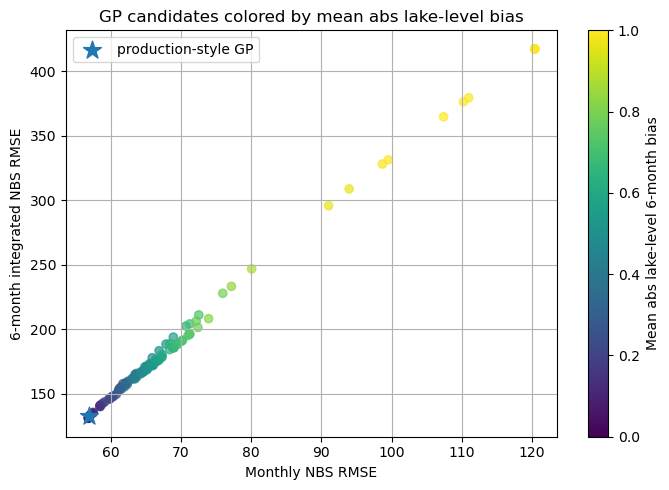

In [14]:
plt.figure(figsize=(7, 5))
plt.scatter(
    eval_df["monthly_nbs_rmse"],
    eval_df["six_month_integrated_nbs_rmse"],
    c=eval_df["mean_abs_lake_level_six_month_bias"],
    alpha=0.7,
)

plt.scatter(
    baseline_metrics["monthly_nbs_rmse"],
    baseline_metrics["six_month_integrated_nbs_rmse"],
    marker="*",
    s=180,
    label="production-style GP",
)

plt.xlabel("Monthly NBS RMSE")
plt.ylabel("6-month integrated NBS RMSE")
plt.title("GP candidates colored by mean abs lake-level bias")
plt.colorbar(label="Mean abs lake-level 6-month bias")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

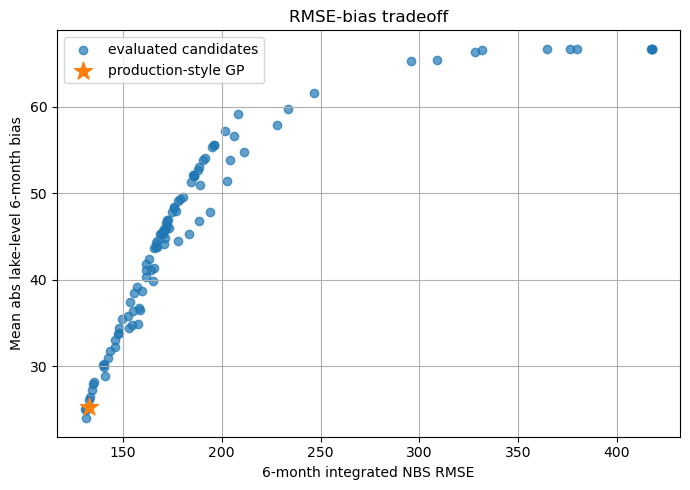

In [15]:
plt.figure(figsize=(7, 5))
plt.scatter(
    eval_df["six_month_integrated_nbs_rmse"],
    eval_df["mean_abs_lake_level_six_month_bias"],
    alpha=0.7,
    label="evaluated candidates",
)

plt.scatter(
    baseline_metrics["six_month_integrated_nbs_rmse"],
    baseline_metrics["mean_abs_lake_level_six_month_bias"],
    marker="*",
    s=180,
    label="production-style GP",
)

plt.xlabel("6-month integrated NBS RMSE")
plt.ylabel("Mean abs lake-level 6-month bias")
plt.title("RMSE-bias tradeoff")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 13. Select a bias-aware candidate

Selection rule:

Choose the candidate with the lowest mean absolute lake-level 6-month bias among models whose 6-month RMSE is within 2% of the production-style GP baseline.

This reflects the operational goal: do not sacrifice much RMSE, but reduce systematic drift.

In [16]:
rmse_tolerance = 1.02

candidate_pool = eval_df[
    eval_df["six_month_integrated_nbs_rmse"]
    <= baseline_metrics["six_month_integrated_nbs_rmse"] * rmse_tolerance
].copy()

if candidate_pool.empty:
    print("No candidates within RMSE tolerance; selecting lowest bias overall.")
    selected = eval_df.sort_values("mean_abs_lake_level_six_month_bias").iloc[0]
else:
    selected = candidate_pool.sort_values(
        ["mean_abs_lake_level_six_month_bias", "six_month_integrated_nbs_rmse"]
    ).iloc[0]

selected

matern_length_scale                      81.315541
rq_alpha                                  4.334743
rq_length_scale                          84.793242
gp_alpha                                  0.013464
label                                 candidate_gp
monthly_nbs_rmse                         56.814757
six_month_integrated_nbs_rmse           131.145795
six_month_integrated_nbs_bias            22.023145
mean_abs_lake_level_six_month_bias       24.011423
max_abs_lake_level_six_month_bias        61.903806
overall_scaled_r2                         0.759892
superior_six_month_bias                  61.903806
michigan-huron_six_month_bias            15.107941
erie_six_month_bias                       15.05739
ontario_six_month_bias                   -3.976556
Name: 0, dtype: object

In [17]:
selected_hyperparams = [
    selected["matern_length_scale"],
    selected["rq_alpha"],
    selected["rq_length_scale"],
    selected["gp_alpha"],
]

selected_gp = build_gp_from_hyperparams(selected_hyperparams)
selected_gp.fit(X_train_scaled, y_train_scaled)
y_pred_selected_scaled = selected_gp.predict(X_test_scaled)

selected_metrics = evaluate_prediction(y_pred_selected_scaled, "bias_aware_multiobjective_gp")

pd.DataFrame([baseline_metrics, selected_metrics])

,label,monthly_nbs_rmse,six_month_integrated_nbs_rmse,six_month_integrated_nbs_bias,mean_abs_lake_level_six_month_bias,max_abs_lake_level_six_month_bias,overall_scaled_r2,superior_six_month_bias,michigan-huron_six_month_bias,erie_six_month_bias,ontario_six_month_bias
0,production_style_gp,56.803424,132.921300,19.449344,25.324559,65.309089,0.760849,65.309089,15.201193,9.037524,-11.750429
1,bias_aware_multiobjective_gp,56.814757,131.145795,22.023145,24.011423,61.903806,0.759892,61.903806,15.107941,15.057390,-3.976556


## 14. Integrated metrics by lake and window

In [18]:
def integrated_metrics_by_lake(y_true_df, y_pred_df, windows=(1, 3, 6)):
    rows = []

    for lake in lakes:
        for window in windows:
            yt_all, yp_all = lake_window_values(y_true_df, y_pred_df, lake, window=window)

            rows.append({
                "Lake": lake,
                "Window": window,
                "RMSE": rmse(yt_all, yp_all),
                "R2": r2_score(yt_all, yp_all),
                "Bias": np.mean(yp_all - yt_all),
            })

    return pd.DataFrame(rows)


y_true_df = unscale_to_df(y_test_scaled, y_scaler, y_test.index, y_test.columns)
y_pred_baseline_df = unscale_to_df(y_pred_baseline_scaled, y_scaler, y_test.index, y_test.columns)
y_pred_selected_df = unscale_to_df(y_pred_selected_scaled, y_scaler, y_test.index, y_test.columns)

integrated_baseline = integrated_metrics_by_lake(y_true_df, y_pred_baseline_df)
integrated_baseline["Model"] = "production_style_gp"

integrated_selected = integrated_metrics_by_lake(y_true_df, y_pred_selected_df)
integrated_selected["Model"] = "bias_aware_multiobjective_gp"

integrated_df = pd.concat([integrated_baseline, integrated_selected], ignore_index=True)

integrated_df

,Lake,Window,RMSE,R2,Bias,Model
0,superior,1,35.671631,0.765296,9.924308,production_style_gp
1,superior,3,63.779169,0.866773,31.492529,production_style_gp
2,superior,6,102.359061,0.832564,65.309089,production_style_gp
3,michigan-huron,1,30.476151,0.811208,1.908450,production_style_gp
4,michigan-huron,3,53.346384,0.896046,6.755277,production_style_gp
5,michigan-huron,6,70.174607,0.911244,15.201193,production_style_gp
6,erie,1,78.891195,0.769743,1.164407,production_style_gp
7,erie,3,131.845073,0.883787,4.005942,production_style_gp
8,erie,6,178.496932,0.899554,9.037524,production_style_gp
9,ontario,1,66.943516,0.775224,-2.515635,production_style_gp


In [19]:
integrated_summary = (
    integrated_df
    .groupby(["Model", "Window"], as_index=False)
    .agg(
        RMSE=("RMSE", "mean"),
        R2=("R2", "mean"),
        Bias=("Bias", "mean"),
        MeanAbsBias=("Bias", lambda x: np.mean(np.abs(x))),
        MaxAbsBias=("Bias", lambda x: np.max(np.abs(x))),
    )
    .sort_values(["Window", "RMSE"])
)

integrated_summary

,Model,Window,RMSE,R2,Bias,MeanAbsBias,MaxAbsBias
0,bias_aware_multiobjective_gp,1,52.987808,0.780731,3.009263,3.624177,9.413525
3,production_style_gp,1,52.995623,0.780368,2.620382,3.878200,9.924308
1,bias_aware_multiobjective_gp,3,89.758673,0.885431,10.281240,11.352580,29.851055
4,production_style_gp,3,90.638243,0.883061,9.050069,12.076806,31.492529
2,bias_aware_multiobjective_gp,6,124.382126,0.889768,22.023145,24.011423,61.903806
5,production_style_gp,6,126.007879,0.886349,19.449344,25.324559,65.309089


## 15. Plot integrated RMSE and bias

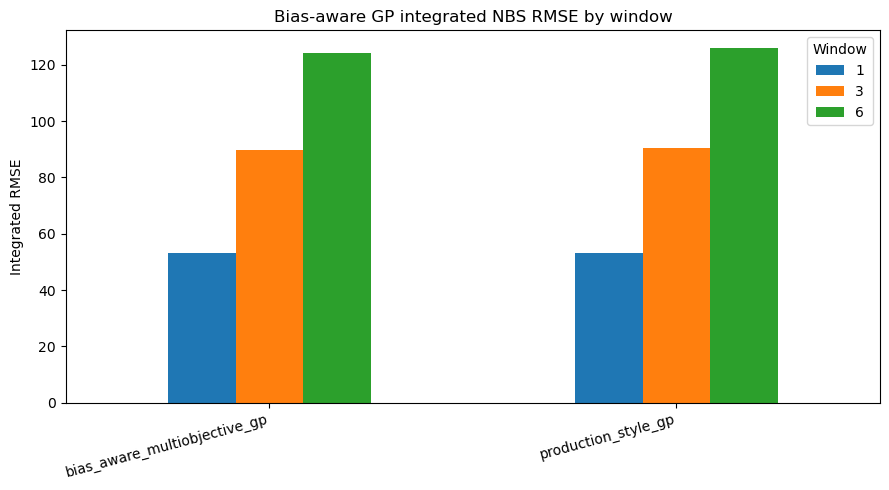

In [20]:
plot_df = integrated_summary.pivot(index="Model", columns="Window", values="RMSE")

ax = plot_df.plot(kind="bar", figsize=(9, 5))
ax.set_ylabel("Integrated RMSE")
ax.set_title("Bias-aware GP integrated NBS RMSE by window")
ax.set_xlabel("")
ax.legend(title="Window")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

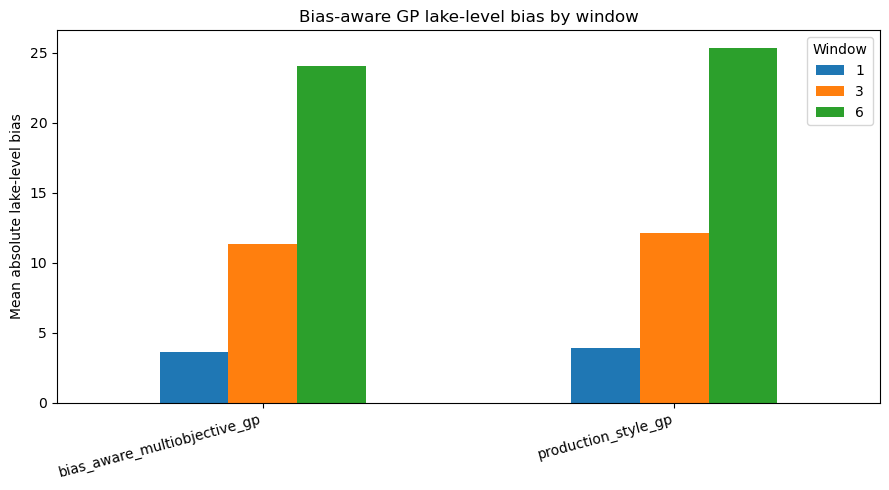

In [21]:
plot_df = integrated_summary.pivot(index="Model", columns="Window", values="MeanAbsBias")

ax = plot_df.plot(kind="bar", figsize=(9, 5))
ax.set_ylabel("Mean absolute lake-level bias")
ax.set_title("Bias-aware GP lake-level bias by window")
ax.set_xlabel("")
ax.legend(title="Window")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## 16. Notes and interpretation

Questions to answer:

- Does adding lake-level bias as an objective reduce cumulative drift?
- Is the selected candidate within an acceptable RMSE tolerance?
- Does bias improve for all lakes or only some lakes?
- Does the selected candidate reduce mean absolute lake-level bias without increasing max absolute bias?
- Should the next version use `max_abs_lake_level_six_month_bias` instead of mean absolute bias?

In [22]:
# Optional: save outputs
# output_dir = Path(input_dir) / "analysis_outputs"
# output_dir.mkdir(parents=True, exist_ok=True)
# eval_df.to_csv(output_dir / "gp_bias_aware_candidate_log.csv", index=False)
# pareto_df.to_csv(output_dir / "gp_bias_aware_pareto.csv", index=False)
# integrated_df.to_csv(output_dir / "gp_bias_aware_integrated_by_lake.csv", index=False)
# integrated_summary.to_csv(output_dir / "gp_bias_aware_integrated_summary.csv", index=False)